# Multiplexing visualization — zoom-region cascade (v4)

Self-contained. Same dataset, same processing, same channel colors as
`Figure_8_multiplexing_visualization.ipynb` / `_v2`.

Layout is a three-step magnifier cascade:

1. **Cell overview** with a highlighted square region (yellow callout box).
2. **Zoom panel** — **every** trajectory detected inside that region, drawn at its
   true position in the cell and all styled identically: **green for Ch 0 and
   magenta for Ch 1**, the same channel colors used everywhere else in the figure.
   A light **gray circle** marks the one track per channel whose crops appear in
   the montage below; it is deliberately not a channel color, so it reads as a
   callout rather than as data. The same two tracks are marked on the cell
   overview with a **thin white circle**, at the same physical radius, so the
   reader can place them in the whole cell.
3. **Crop montage** at the bottom, spanning the full width of the two panels
   above it, one tile per time point.

**No particle is chosen by hand.** The region is placed automatically on the part
of the cell holding the most trajectories, and the montage takes the
longest-lived eligible track of each channel *inside that region*, so the crops
always belong to something visible in the panel above. `ZOOM_CENTER_XY`,
`MONTAGE_PARTICLE_CH0` and `MONTAGE_PARTICLE_CH1` are available if you ever want
to pin any of it manually.

Everything is placed on an explicit inch grid, so the montage columns start at
the cell overview's left edge and end at the zoom panel's right edge.


In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patheffects as path_effects
from matplotlib.patches import ConnectionPatch
from scipy.ndimage import gaussian_filter
from matplotlib_scalebar.scalebar import ScaleBar
import microlive.microscopy as mi

# Channel colors — used for the trajectories, the circles, the montage borders
# and the montage row labels, so one color always means one channel.
CH0_COLOR = '#00C033'
CH1_COLOR = '#FF00FF'
CH0_TRAJECTORY_LABEL = 'Anti-SunTag-IB-mEGFP'
CH1_TRAJECTORY_LABEL = 'Anti-UTag-IB(\u0394Cys)-HaloTag'

# Callout colors (not a data channel).
ZOOM_BOX_COLOR = '#FFD400'
FRAME_COLOR = '#222222'

# One type scale for the whole figure.
FS_TICK = 12       # montage time stamps
FS_LABEL = 13      # channel legend, montage row labels
FS_SCALEBAR = 13

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': FS_TICK,
    'axes.labelsize': FS_LABEL,
    'xtick.labelsize': FS_TICK,
    'ytick.labelsize': FS_TICK,
    'figure.dpi': 120,
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,          # keep text editable in Illustrator / Inkscape
    'ps.fonttype': 42,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': FRAME_COLOR,
    'axes.linewidth': 1.6,
    'axes.labelweight': 'bold',
    'xtick.color': FRAME_COLOR,
    'ytick.color': FRAME_COLOR,
    'lines.solid_capstyle': 'round',
    'lines.solid_joinstyle': 'round',
})

In [2]:
# Parameters
DATASET_FILENAME = '20260814_multiplexing.lif'
selected_series = 'Series004'  # Name or zero-based index

MINIMUM_TRAJECTORY_FRAMES = 7
REJECT_TRAJECTORY_GAPS = True
DISPLAY_FRAME_COUNT = 15
DISPLAY_START_FRAME = None
preview_frame = None
crop_size = 15

SAVE_FIGURE = True
FIGURE_OUTPUT_DIR = None
FIGURE_BASENAME = 'Figure_8_multiplexing_v4'
FIGURE_DPI = 600

# Display settings
DISPLAY_MIN_PERCENTILE = 0.5
DISPLAY_MAX_PERCENTILE = 99.9
TRACKING_MAX_PERCENTILE = 99.95
DISPLAY_GAUSSIAN_SIGMA = 0.6
DISPLAY_GAMMA = 1.45
CROP_DISPLAY_MAX_PERCENTILE = 99.0
SPOT_SIZE_PX = 5

# ------------------------------------------------------------- zoom region (v4)
# Square region of the cell magnified into the trajectory panel. The panel shows
# every trajectory whose centroid falls inside it -- nothing is hand-picked.
ZOOM_SIZE_PX = 100            # side of the region, in camera pixels
ZOOM_CENTER_XY = (340, 200) #None         # None -> placed automatically on the densest area
# Which trajectories populate the zoom panel. Loosen these for a denser panel;
# gapped tracks are drawn as separate polylines, never as a jump across the gap.
ZOOM_MIN_TRAJECTORY_FRAMES = 7
ZOOM_REJECT_TRAJECTORY_GAPS = True
ZOOM_TRAJECTORY_FRAMES = 'full'   # 'full' | 'display_window'
ZOOM_TRACK_LINEWIDTH = 1.7        # every trajectory, drawn the same way
ZOOM_SCALEBAR_FRACTION = 0.25
ZOOM_SHOW_IMAGE = False       # True draws the raw region behind the trajectories

# ------------------------------------------------------------- montage source
# Which trajectory supplies the crops, per channel, ranked longest-first among
# the eligible tracks that sit fully inside the zoom region:
#   0 = longest, 1 = second longest, ...  (None behaves as 0)
# This is the same meaning selected_particle_ch0 / selected_particle_ch1 had in
# the original notebook. The cell below prints the ranks actually on offer.
MONTAGE_RANK_CH0 = 1
MONTAGE_RANK_CH1 = 0
# Alternatively pin an exact particle id from the tracking table (e.g. 27, not a
# 0/1/2 rank). When set, it overrides the rank above.
MONTAGE_PARTICLE_ID_CH0 = None
MONTAGE_PARTICLE_ID_CH1 = None
# Neutral callout marking the two tracks the crops come from. Gray, not a channel
# color, so it annotates without competing with the trajectories.
MONTAGE_CIRCLE_COLOR = '#A0A0A0'
MONTAGE_CIRCLE_LINEWIDTH = 1.3
MONTAGE_CIRCLE_LINESTYLE = '-'      # e.g. (0, (5, 3)) for a dashed callout
MONTAGE_CIRCLE_MIN_RADIUS_PX = 9.0
MONTAGE_CIRCLE_SCALE = 1.5      # multiple of the track's own radius
MONTAGE_CIRCLE_MARGIN_PX = 4.0  # clearance kept between circle and panel frame
# The same two tracks marked on the cell overview. White dashes read over the
# dark image the way the gray dashes read over the white zoom panel.
CELL_MARKER_COLOR = 'white'
CELL_MARKER_LINEWIDTH = 1.3
CELL_MARKER_LINESTYLE = '-'         # e.g. (0, (4, 3)) for a dashed callout
CELL_MARKER_HALO_EXTRA_LW = 1.2     # dark outline keeping the ring legible on the image
CELL_MARKER_MIN_RADIUS_PX = 12.0

# ------------------------------------------------------------- layout (inches)
TILE_IN = 0.72            # side of one montage tile
TILE_GAP_IN = 0.045       # gap between consecutive time points
MONT_ROW_GAP_IN = 0.080   # gap between the Ch 0 and Ch 1 montage rows
PANEL_GAP_IN = 0.45       # cell overview -> zoom panel
GUTTER_IN = 0.60          # reserved left of everything for the row labels
BLOCK_GAP_IN = 0.40       # panel row -> montage block
TIME_H_IN = 0.32          # time stamps under the montage
TITLE_H_IN = 0.32         # channel legend above the zoom panel
MARGIN_IN = 0.12          # outer margin on all four sides
ROW_LABEL_PAD_IN = 0.14   # 'Ch 0' / 'Ch 1' montage labels -> first tile
TIME_LABEL_PAD_IN = 0.09  # montage bottom edge -> time stamps

In [3]:
# Load the movie and the tracking table
working_dir = Path.cwd().resolve()
data_root_candidates = [
    working_dir / 'data',
    working_dir / 'notebooks' / 'Figure_8_Multiplexing' / 'data',
]
data_root = next(
    (path for path in data_root_candidates if (path / DATASET_FILENAME).is_file()),
    None,
)
if data_root is None:
    searched = '\n'.join(str(path / DATASET_FILENAME) for path in data_root_candidates)
    raise FileNotFoundError(f'Could not find {DATASET_FILENAME}. Searched:\n{searched}')
lif_file_path = data_root / DATASET_FILENAME

reader = mi.ReadLif(
    lif_file_path, show_metadata=False, save_tif=False, save_png=False, format='TZYXC'
)
read_output = reader.read()
list_images, list_names, pixel_xy_um = read_output[:3]
list_time_intervals = read_output[6]

def resolve_series_selection(selection, available_names):
    if isinstance(selection, (int, np.integer)):
        index = int(selection)
        if index < 0 or index >= len(available_names):
            raise IndexError(f'selected_series index {index} is outside 0..{len(available_names)-1}.')
        return index, available_names[index]
    if selection not in available_names:
        raise ValueError(f'Unknown series {selection!r}. Available: {available_names}')
    return available_names.index(selection), selection

selected_series_index, selected_series = resolve_series_selection(selected_series, list_names)
movie = list_images[selected_series_index]  # T, Z, Y, X, C
frame_interval_s = float(list_time_intervals[selected_series_index])
if movie.ndim != 5 or movie.shape[-1] < 2:
    raise ValueError(f'{selected_series} must be TZYXC with at least two channels; got {movie.shape}.')

dataset_id = lif_file_path.stem
results_candidates = [
    data_root / 'final_data',
    Path('/Users/nzlab-la/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Submitted/UTag paper/Revision_data/Multiplexing/final_data'),
]
tracking_files = []
for base in results_candidates:
    exact_file = base / f'results_{dataset_id}_{selected_series}' / f'tracking_{dataset_id}_{selected_series}.csv'
    if exact_file.is_file():
        tracking_files = [exact_file]
        break
    if base.exists():
        tracking_files = sorted(base.glob(f'*{dataset_id}_{selected_series}/tracking_*{dataset_id}_{selected_series}.csv'))
        if tracking_files:
            break
if not tracking_files:
    raise FileNotFoundError(
        f'No tracking CSV matches dataset={dataset_id!r}, series={selected_series!r}.'
    )
tracking_file = tracking_files[0]
df_all = pd.read_csv(tracking_file)
channel_column = 'spot_type' if 'spot_type' in df_all.columns else 'channel'
required_columns = {channel_column, 'particle', 'frame', 'x', 'y'}
missing_columns = sorted(required_columns.difference(df_all.columns))
if missing_columns:
    raise ValueError(f'{tracking_file.name} is missing columns: {missing_columns}')
df_channel = {0: df_all[df_all[channel_column] == 0].copy(),
              1: df_all[df_all[channel_column] == 1].copy()}

def build_eligible_trajectories(df_ch):
    """Tracks long enough (and unbroken enough) to supply a crop montage."""
    rows = []
    for particle_id, trajectory in df_ch.groupby('particle', sort=True):
        trajectory = trajectory.sort_values('frame').drop_duplicates('frame')
        frames = np.sort(trajectory['frame'].astype(int).unique())
        has_gaps = len(frames) > 1 and np.any(np.diff(frames) != 1)
        if len(frames) < MINIMUM_TRAJECTORY_FRAMES or (REJECT_TRAJECTORY_GAPS and has_gaps):
            continue
        rows.append({
            'original_particle': particle_id,
            'n_unique_frames': len(frames),
            'first_frame': int(frames[0]),
            'last_frame': int(frames[-1]),
            'displacement_px': float(np.hypot(
                trajectory['x'].iloc[-1] - trajectory['x'].iloc[0],
                trajectory['y'].iloc[-1] - trajectory['y'].iloc[0],
            )),
            'mean_x': float(trajectory['x'].mean()),
            'mean_y': float(trajectory['y'].mean()),
            'circle_radius_px': max(
                float(np.hypot(trajectory['x'] - trajectory['x'].mean(),
                               trajectory['y'] - trajectory['y'].mean()).max())
                * MONTAGE_CIRCLE_SCALE,
                MONTAGE_CIRCLE_MIN_RADIUS_PX,
            ),
        })
    columns = ['original_particle', 'n_unique_frames', 'first_frame', 'last_frame',
               'displacement_px', 'mean_x', 'mean_y', 'circle_radius_px']
    return pd.DataFrame(rows, columns=columns).sort_values(
        ['n_unique_frames', 'displacement_px', 'original_particle'],
        ascending=[False, False, True],
    ).reset_index(drop=True)

eligible_trajectories = {channel: build_eligible_trajectories(df_channel[channel])
                         for channel in (0, 1)}
image_h, image_w = movie.shape[2], movie.shape[3]
print(f'{selected_series}: {image_h}x{image_w} px, {pixel_xy_um:.4f} um/px, '
      f'{frame_interval_s:g} s/frame')
print(f'Montage-eligible tracks in the whole cell: '
      f"Ch0={len(eligible_trajectories[0])}, Ch1={len(eligible_trajectories[1])}")

Series004: 512x512 px, 0.1299 um/px, 1 s/frame
Montage-eligible tracks in the whole cell: Ch0=27, Ch1=29


In [4]:
# ---------------------------------------------------------------------------
# Place the zoom region, collect every trajectory inside it, and let the montage
# take the longest eligible track of each channel from that same region. Nothing
# is selected by hand. Trajectories stay in camera pixel coordinates so they are
# drawn at their true position in the cell.
# ---------------------------------------------------------------------------
def contiguous_segments(trajectory):
    """Split a trajectory wherever a frame is missing.

    Gapped tracks become several polylines instead of one, so relaxing
    ZOOM_REJECT_TRAJECTORY_GAPS never draws a straight jump across frames the
    particle was not detected in.
    """
    frames = trajectory['frame'].astype(int).to_numpy()
    x = trajectory['x'].to_numpy(dtype=float)
    y = trajectory['y'].to_numpy(dtype=float)
    split_at = np.flatnonzero(np.diff(frames) != 1) + 1
    return [(xs, ys) for xs, ys in zip(np.split(x, split_at), np.split(y, split_at)) if xs.size]

def panel_entry(particle_id, trajectory):
    """(particle, mean_x, mean_y, segments) for one track, trimmed to the panel window."""
    trajectory = trajectory.sort_values('frame').drop_duplicates('frame')
    if ZOOM_TRAJECTORY_FRAMES == 'display_window' and DISPLAY_START_FRAME is not None:
        window = range(int(DISPLAY_START_FRAME), int(DISPLAY_START_FRAME) + DISPLAY_FRAME_COUNT)
        trajectory = trajectory[trajectory['frame'].isin(window)]
    elif ZOOM_TRAJECTORY_FRAMES not in ('full', 'display_window'):
        raise ValueError(
            f'Unknown ZOOM_TRAJECTORY_FRAMES={ZOOM_TRAJECTORY_FRAMES!r}; '
            "use 'full' or 'display_window'."
        )
    if trajectory.empty:
        return None
    return (particle_id, float(trajectory['x'].mean()), float(trajectory['y'].mean()),
            contiguous_segments(trajectory))

def zoom_panel_tracks(df_ch):
    """(particle, mean_x, mean_y, segments) for every track the panel will draw."""
    tracks = []
    for particle_id, trajectory in df_ch.groupby('particle', sort=True):
        frames = np.sort(trajectory['frame'].astype(int).unique())
        if len(frames) < ZOOM_MIN_TRAJECTORY_FRAMES:
            continue
        if ZOOM_REJECT_TRAJECTORY_GAPS and len(frames) > 1 and np.any(np.diff(frames) != 1):
            continue
        entry = panel_entry(particle_id, trajectory)
        if entry is not None:
            tracks.append(entry)
    return tracks

zoom_tracks = {channel: zoom_panel_tracks(df_channel[channel]) for channel in (0, 1)}

zoom_radius = min(ZOOM_SIZE_PX / 2.0, min(image_w, image_h) / 2.0)

def clamp_center(center_x, center_y):
    return (float(np.clip(center_x, zoom_radius, image_w - zoom_radius)),
            float(np.clip(center_y, zoom_radius, image_h - zoom_radius)))

def count_inside(center_x, center_y, rows):
    """rows: iterable of (mean_x, mean_y)."""
    return sum(1 for mx, my in rows
               if abs(mx - center_x) <= zoom_radius and abs(my - center_y) <= zoom_radius)

panel_centroids = [(mx, my) for channel in (0, 1) for _, mx, my, _ in zoom_tracks[channel]]
def circle_fits_region(mean_x, mean_y, radius, center_x, center_y):
    """True when the whole callout circle stays inside the region.

    Centroid-inside is not enough: the track that feeds the montage has to be
    fully visible in the panel, otherwise its callout is clipped by the frame.
    """
    limit = zoom_radius - radius - MONTAGE_CIRCLE_MARGIN_PX
    return abs(mean_x - center_x) <= limit and abs(mean_y - center_y) <= limit

eligible_circles = {
    channel: list(zip(eligible_trajectories[channel]['mean_x'],
                      eligible_trajectories[channel]['mean_y'],
                      eligible_trajectories[channel]['circle_radius_px']))
    for channel in (0, 1)
}

def n_montage_candidates(channel, center_x, center_y):
    return sum(1 for mx, my, r in eligible_circles[channel]
               if circle_fits_region(mx, my, r, center_x, center_y))

if ZOOM_CENTER_XY is not None:
    zoom_center_x, zoom_center_y = clamp_center(*(float(v) for v in ZOOM_CENTER_XY))
else:
    # Try every trajectory centroid as a candidate window centre and keep the one
    # holding the most tracks, restricted to windows that can still feed both
    # montage rows. Ties break toward the tightest cluster.
    candidates = []
    for raw_x, raw_y in panel_centroids:
        center_x, center_y = clamp_center(raw_x, raw_y)
        if min(n_montage_candidates(c, center_x, center_y) for c in (0, 1)) < 1:
            continue
        n_tracks = count_inside(center_x, center_y, panel_centroids)
        spread = float(np.mean([max(abs(mx - center_x), abs(my - center_y))
                                for mx, my in panel_centroids
                                if abs(mx - center_x) <= zoom_radius
                                and abs(my - center_y) <= zoom_radius]))
        candidates.append((-n_tracks, spread, center_x, center_y))
    if not candidates:
        raise ValueError(
            f'No {ZOOM_SIZE_PX} px region fully contains an eligible track in both '
            'channels. Increase ZOOM_SIZE_PX or relax MINIMUM_TRAJECTORY_FRAMES.'
        )
    _, _, zoom_center_x, zoom_center_y = min(candidates)

zoom_x0, zoom_x1 = zoom_center_x - zoom_radius, zoom_center_x + zoom_radius
zoom_y0, zoom_y1 = zoom_center_y - zoom_radius, zoom_center_y + zoom_radius

def centroid_inside_region(mean_x, mean_y):
    return (zoom_x0 <= mean_x <= zoom_x1) and (zoom_y0 <= mean_y <= zoom_y1)

region_tracks = {channel: [entry for entry in zoom_tracks[channel]
                           if centroid_inside_region(entry[1], entry[2])]
                 for channel in (0, 1)}

# ------------------------------------------------------------ montage particles
def region_eligible(channel):
    """Montage candidates for this channel, longest first.

    A candidate has to (a) sit fully inside the zoom region, so its callout is
    not clipped, and (b) be long enough to fill the montage. Without (b),
    lowering MINIMUM_TRAJECTORY_FRAMES offers ranks that cannot supply
    DISPLAY_FRAME_COUNT frames and fail further down.
    """
    table = eligible_trajectories[channel]
    keep = [circle_fits_region(mean_x, mean_y, radius, zoom_center_x, zoom_center_y)
            and n_frames >= DISPLAY_FRAME_COUNT
            for mean_x, mean_y, radius, n_frames in zip(table['mean_x'], table['mean_y'],
                                                        table['circle_radius_px'],
                                                        table['n_unique_frames'])]
    return table[keep].reset_index(drop=True)

def montage_particle(channel, rank, particle_id):
    table = eligible_trajectories[channel]
    fits = region_eligible(channel)
    if particle_id is not None:
        if particle_id not in set(table['original_particle']):
            known = ', '.join(str(v) for v in table['original_particle'])
            raise ValueError(
                f'MONTAGE_PARTICLE_ID_CH{channel}={particle_id} is not an eligible particle id. '
                f'Eligible Ch{channel} ids are: {known}. To choose by length instead, leave it '
                f'None and set MONTAGE_RANK_CH{channel} (0 = longest, 1 = second longest, ...).'
            )
        if particle_id not in set(fits['original_particle']):
            print(f'Warning: Ch{channel} particle {particle_id} does not sit fully inside the '
                  'zoom region; its callout circle will be clipped by the panel frame.')
        return particle_id
    if fits.empty:
        raise ValueError(f'Ch{channel} has no eligible trajectory fully inside the zoom region.')
    index = 0 if rank is None else int(rank)
    if not 0 <= index < len(fits):
        raise IndexError(
            f'MONTAGE_RANK_CH{channel}={index} is out of range: the zoom region offers '
            f'{len(fits)} eligible Ch{channel} track(s), so valid ranks are 0..{len(fits) - 1}. '
            'Enlarge ZOOM_SIZE_PX for more choices.'
        )
    return fits['original_particle'].iloc[index]

for channel in (0, 1):
    offered = region_eligible(channel)
    listing = ', '.join(f'{rank}=particle {pid} ({frames} fr)' for rank, (pid, frames)
                        in enumerate(zip(offered['original_particle'],
                                         offered['n_unique_frames'])))
    print(f'Ch{channel} montage ranks available in the region: {listing}')

p0_id = montage_particle(0, MONTAGE_RANK_CH0, MONTAGE_PARTICLE_ID_CH0)
p1_id = montage_particle(1, MONTAGE_RANK_CH1, MONTAGE_PARTICLE_ID_CH1)
p0_df = df_channel[0][df_channel[0]['particle'] == p0_id].sort_values('frame')
p1_df = df_channel[1][df_channel[1]['particle'] == p1_id].sort_values('frame')

# The montage tracks are picked with MINIMUM_TRAJECTORY_FRAMES / REJECT_TRAJECTORY_GAPS,
# which are looser than the panel's ZOOM_* filters, so the track feeding a crop strip can
# be one the panel dropped -- and its gray callout then encloses nothing. Draw it anyway:
# contiguous_segments splits it at the missing frames, so relaxing the panel filter for
# these two tracks never draws a straight jump across a frame the particle was not in.
def ensure_track_drawn(channel, particle_id):
    if any(entry[0] == particle_id for entry in region_tracks[channel]):
        return
    entry = panel_entry(particle_id,
                        df_channel[channel][df_channel[channel]['particle'] == particle_id])
    if entry is None:
        raise ValueError(
            f'Ch{channel} particle {particle_id} feeds the montage but has no points left in '
            'the panel window, so its callout circle cannot be filled.'
        )
    region_tracks[channel].append(entry)
    print(f'Note: Ch{channel} particle {particle_id} feeds the montage but the panel filters '
          '(ZOOM_MIN_TRAJECTORY_FRAMES / ZOOM_REJECT_TRAJECTORY_GAPS) had dropped it; '
          'drawn anyway so its callout circle is not empty.')

ensure_track_drawn(0, p0_id)
ensure_track_drawn(1, p1_id)

# ------------------------------------------------------------ montage time window
def contiguous_runs(frames):
    frames = np.sort(np.unique(np.asarray(frames, dtype=int)))
    if frames.size == 0:
        return []
    split_at = np.flatnonzero(np.diff(frames) != 1) + 1
    return [run for run in np.split(frames, split_at) if run.size]

def observed_frames(channel, particle_id):
    return set(df_channel[channel][df_channel[channel]['particle'] == particle_id]['frame'].astype(int))

def longest_shared_run(particle_0, particle_1):
    """Longest stretch of consecutive frames in which both particles are detected."""
    shared = sorted(observed_frames(0, particle_0) & observed_frames(1, particle_1))
    return max((len(run) for run in contiguous_runs(shared)), default=0)

def workable_rank_pairs():
    """(rank_ch0, particle_0, rank_ch1, particle_1, run) pairs long enough for the montage.

    The two ranks are picked one channel at a time, so nothing guarantees the two
    tracks are alive at the same time. This lists the combinations that are, best
    (lowest-rank, longest-overlap) first.
    """
    offers = {channel: region_eligible(channel) for channel in (0, 1)}
    pairs = [(rank_0, particle_0, rank_1, particle_1, longest_shared_run(particle_0, particle_1))
             for rank_0, particle_0 in enumerate(offers[0]['original_particle'])
             for rank_1, particle_1 in enumerate(offers[1]['original_particle'])]
    return sorted((pair for pair in pairs if pair[4] >= DISPLAY_FRAME_COUNT),
                  key=lambda pair: (pair[0] + pair[2], -pair[4]))

shared_frames = sorted(set(p0_df['frame'].astype(int)) & set(p1_df['frame'].astype(int)))
if DISPLAY_START_FRAME is None:
    suitable_runs = [run for run in contiguous_runs(shared_frames) if len(run) >= DISPLAY_FRAME_COUNT]
    if not suitable_runs:
        longest = max((len(run) for run in contiguous_runs(shared_frames)), default=0)
        pairs = workable_rank_pairs()
        if pairs:
            listing = '; '.join(
                f'CH0={rank_0}/CH1={rank_1} (particles {particle_0}/{particle_1}, {run} fr)'
                for rank_0, particle_0, rank_1, particle_1, run in pairs[:6]
            )
            advice = (f'Rank pairs whose tracks do overlap for {DISPLAY_FRAME_COUNT}+ consecutive '
                      f'frames: {listing}. Set MONTAGE_RANK_CH0 / MONTAGE_RANK_CH1 to one of them, '
                      f'or reduce DISPLAY_FRAME_COUNT to {longest}.')
        else:
            advice = (f'No rank pair in this region overlaps for {DISPLAY_FRAME_COUNT} consecutive '
                      f'frames. Reduce DISPLAY_FRAME_COUNT to {longest} or enlarge ZOOM_SIZE_PX.')
        raise ValueError(
            f'Ch0 particle {p0_id} and Ch1 particle {p1_id} are not both detected for '
            f'{DISPLAY_FRAME_COUNT} consecutive frames; their longest shared run is {longest}. '
            + advice
        )
    time_frames = suitable_runs[0][:DISPLAY_FRAME_COUNT].astype(int).tolist()
else:
    time_frames = list(range(int(DISPLAY_START_FRAME), int(DISPLAY_START_FRAME) + DISPLAY_FRAME_COUNT))
    missing_shared = sorted(set(time_frames).difference(shared_frames))
    if missing_shared:
        raise ValueError(f'The montage trajectories are missing requested frames: {missing_shared}')
if min(time_frames) < 0 or max(time_frames) >= movie.shape[0]:
    raise IndexError(f'Display frames {time_frames[0]}..{time_frames[-1]} exceed movie range 0..{movie.shape[0]-1}.')
if preview_frame is None:
    preview_frame = time_frames[0]
preview_frame = int(preview_frame)
if preview_frame not in shared_frames:
    raise ValueError(
        f'preview_frame={preview_frame} is not observed in both montage trajectories. '
        f'Choose one of the shared frames, for example {time_frames[0]}.'
    )
relative_times_s = [(frame - time_frames[0]) * frame_interval_s for frame in time_frames]

# Neutral gray dashed callout around each montage track, so the reader can tell
# which of the trajectories above produced the crop strips below.
def montage_circle_geometry(p_df):
    x = p_df['x'].to_numpy(dtype=float)
    y = p_df['y'].to_numpy(dtype=float)
    center_x, center_y = float(x.mean()), float(y.mean())
    radius = max(float(np.hypot(x - center_x, y - center_y).max()) * MONTAGE_CIRCLE_SCALE,
                 MONTAGE_CIRCLE_MIN_RADIUS_PX)
    return center_x, center_y, radius

montage_circles = {0: montage_circle_geometry(p0_df), 1: montage_circle_geometry(p1_df)}

print(f'Zoom region {2 * zoom_radius:.0f} px ({2 * zoom_radius * pixel_xy_um:.1f} um) '
      f'centred on ({zoom_center_x:.0f}, {zoom_center_y:.0f})')
print(f'Trajectories drawn in the zoom panel: '
      f'Ch0={len(region_tracks[0])}, Ch1={len(region_tracks[1])} '
      f'(total {len(region_tracks[0]) + len(region_tracks[1])})')
print(f'Montage crops from Ch0 particle {p0_id} and Ch1 particle {p1_id}, '
      f'frames {time_frames[0]}..{time_frames[-1]}')

Ch0 montage ranks available in the region: 0=particle 21 (60 fr), 1=particle 35 (29 fr), 2=particle 19 (18 fr)
Ch1 montage ranks available in the region: 0=particle 29 (60 fr), 1=particle 50 (60 fr), 2=particle 37 (60 fr)
Zoom region 100 px (13.0 um) centred on (340, 200)
Trajectories drawn in the zoom panel: Ch0=5, Ch1=7 (total 12)
Montage crops from Ch0 particle 35 and Ch1 particle 29, frames 3..17


In [5]:
# Build the display arrays (identical processing to the original notebook)
def microlive_display_channel(
    frame_zyxc, channel_idx, min_percentile, max_percentile, gaussian_sigma, display_gamma
):
    channel_zyx = frame_zyxc[:, :, :, channel_idx].astype(np.float32)
    channel_2d = np.max(channel_zyx, axis=0)
    clipped = mi.RemoveExtrema(
        channel_2d,
        min_percentile=min_percentile,
        max_percentile=max_percentile,
    ).remove_outliers().astype(np.float32)
    filtered = gaussian_filter(clipped, sigma=gaussian_sigma)
    filtered_min = float(np.min(filtered))
    filtered_max = float(np.max(filtered))
    normalized = np.clip(
        (filtered - filtered_min) / (filtered_max - filtered_min + 1e-8), 0, 1
    )
    return np.power(normalized, display_gamma)

preview_tzyxc = movie[preview_frame]
norm0 = microlive_display_channel(
    preview_tzyxc, 0, DISPLAY_MIN_PERCENTILE, DISPLAY_MAX_PERCENTILE,
    DISPLAY_GAUSSIAN_SIGMA, DISPLAY_GAMMA
)
norm1 = microlive_display_channel(
    preview_tzyxc, 1, DISPLAY_MIN_PERCENTILE, DISPLAY_MAX_PERCENTILE,
    DISPLAY_GAUSSIAN_SIGMA, DISPLAY_GAMMA
)

rgb = np.zeros((movie.shape[2], movie.shape[3], 3), dtype=np.float32)
rgb[:, :, 0] = norm1
rgb[:, :, 1] = norm0
rgb[:, :, 2] = norm1

def extract_crop_15x15(movie_arr, ch_idx, frame_idx, p_df):
    if p_df.empty:
        return np.zeros((crop_size, crop_size), dtype=np.float32)
    row = p_df[p_df['frame'].astype(int) == int(frame_idx)]
    if row.empty:
        raise ValueError(
            f'Particle {p_df["particle"].iloc[0]} has no detection at frame {frame_idx}; '
            'the display window must contain only observed consecutive frames.'
        )
    cx, cy = int(round(row['x'].iloc[0])), int(round(row['y'].iloc[0]))

    f_zyx = movie_arr[frame_idx, :, :, :, ch_idx].astype(np.float32)
    f = np.max(f_zyx, axis=0)
    spot_radius_px = max(1.0, float(SPOT_SIZE_PX // 2))
    filtered_frame = mi.stack.log_filter(f, sigma=spot_radius_px).astype(np.float32)
    H, W = f.shape
    r = crop_size // 2
    ymin, ymax = cy - r, cy + r + 1
    xmin, xmax = cx - r, cx + r + 1
    pad_y_pre, pad_y_post = max(0, -ymin), max(0, ymax - H)
    pad_x_pre, pad_x_post = max(0, -xmin), max(0, xmax - W)
    filtered_crop = filtered_frame[max(0, ymin):min(H, ymax), max(0, xmin):min(W, xmax)]
    if pad_y_pre or pad_y_post or pad_x_pre or pad_x_post:
        filtered_crop = np.pad(filtered_crop, ((pad_y_pre, pad_y_post), (pad_x_pre, pad_x_post)), mode='edge')

    particle_scale = float(np.nanpercentile(filtered_crop, TRACKING_MAX_PERCENTILE))
    if not np.isfinite(particle_scale) or particle_scale <= 0:
        return np.zeros((crop_size, crop_size), dtype=np.float32)
    normalized_crop = np.clip(filtered_crop / particle_scale, 0, 1)
    display_scale = float(np.nanpercentile(normalized_crop, CROP_DISPLAY_MAX_PERCENTILE))
    if not np.isfinite(display_scale) or display_scale <= 0:
        return np.zeros((crop_size, crop_size), dtype=np.float32)
    return np.clip(normalized_crop / display_scale, 0, 1).astype(np.float32)

crops_ch0 = [extract_crop_15x15(movie, 0, t, p0_df) for t in time_frames]
crops_ch1 = [extract_crop_15x15(movie, 1, t, p1_df) for t in time_frames]

Saved Figure_8_multiplexing_v4_20260814_multiplexing_Series004_zoom100px_ch0-35_ch1-29.png / .svg / .pdf to /Users/nzlab-la/Desktop/utag_paper/notebooks/Figure_8_Multiplexing/figures
Figure canvas: 12.270 x 8.290 in (aspect 1.480)


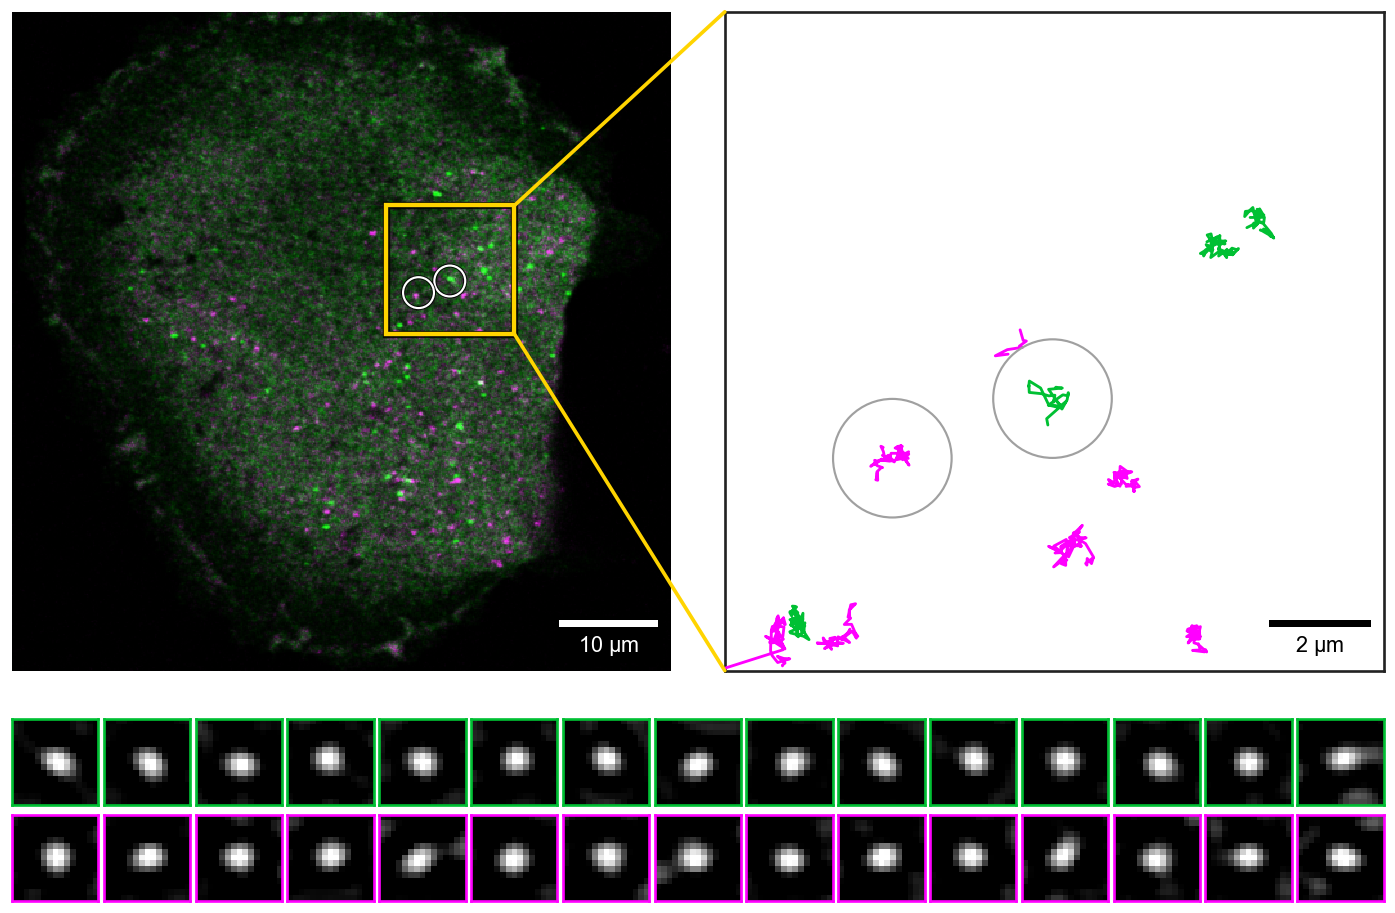

In [6]:
# ---------------------------------------------------------------------------
# Explicit inch grid: cell overview | zoom panel on top, montage spanning the
# full width underneath. Nothing is auto-packed.
# ---------------------------------------------------------------------------
n_time_points = len(time_frames)

montage_w_in = n_time_points * TILE_IN + (n_time_points - 1) * TILE_GAP_IN
panel_side_in = (montage_w_in - PANEL_GAP_IN) / 2.0

montage_bottom_in = MARGIN_IN + TIME_H_IN
montage_top_in = montage_bottom_in + 2 * TILE_IN + MONT_ROW_GAP_IN
panel_bottom_in = montage_top_in + BLOCK_GAP_IN
panel_top_in = panel_bottom_in + panel_side_in

fig_h_in = panel_top_in + TITLE_H_IN + MARGIN_IN
block_left_in = MARGIN_IN + GUTTER_IN
fig_w_in = block_left_in + montage_w_in + MARGIN_IN

fig = plt.figure(figsize=(fig_w_in, fig_h_in), facecolor='white')

def axes_rect(x_in, y_in, w_in, h_in):
    """Inches measured from the bottom-left corner -> figure fraction."""
    return [x_in / fig_w_in, y_in / fig_h_in, w_in / fig_w_in, h_in / fig_h_in]

# ------------------------------------------------------------ cell overview
cell_w_in = panel_side_in * (image_w / image_h)
ax_cell = fig.add_axes(axes_rect(block_left_in, panel_bottom_in, cell_w_in, panel_side_in))
ax_cell.imshow(rgb, interpolation='nearest')
ax_cell.set_facecolor('black')

zoom_box = patches.Rectangle(
    (zoom_x0, zoom_y0), 2 * zoom_radius, 2 * zoom_radius,
    edgecolor=ZOOM_BOX_COLOR, facecolor='none', linewidth=2.6,
    joinstyle='miter', zorder=6,
)
zoom_box.set_path_effects([
    path_effects.Stroke(linewidth=4.4, foreground='black', alpha=0.85),
    path_effects.Normal(),
])
ax_cell.add_patch(zoom_box)
# The two montage tracks located in the whole cell, matching the gray callouts
# in the zoom panel. ax_cell data coordinates are image pixels, so the
# circle geometry carries over unchanged.
for channel in (0, 1):
    marker_x, marker_y, marker_r = montage_circles[channel]
    marker = patches.Circle(
        (marker_x, marker_y), max(marker_r, CELL_MARKER_MIN_RADIUS_PX),
        edgecolor=CELL_MARKER_COLOR, facecolor='none',
        linewidth=CELL_MARKER_LINEWIDTH, linestyle=CELL_MARKER_LINESTYLE, zorder=7,
    )
    marker.set_path_effects([
        path_effects.Stroke(linewidth=CELL_MARKER_LINEWIDTH + CELL_MARKER_HALO_EXTRA_LW,
                            foreground='black', alpha=0.85),
        path_effects.Normal(),
    ])
    ax_cell.add_patch(marker)

ax_cell.add_artist(ScaleBar(
    dx=pixel_xy_um, units='um', length_fraction=0.2, location='lower right',
    box_color='black', color='white', border_pad=0.45, sep=4,
    font_properties={'family': 'Arial', 'size': FS_SCALEBAR},
))
ax_cell.set_xticks([])
ax_cell.set_yticks([])
for spine in ax_cell.spines.values():
    spine.set_visible(False)

# ------------------------------------------------------------ zoom panel
zoom_left_in = block_left_in + cell_w_in + PANEL_GAP_IN
ax_zoom = fig.add_axes(axes_rect(zoom_left_in, panel_bottom_in, panel_side_in, panel_side_in))

if ZOOM_SHOW_IMAGE:
    ax_zoom.imshow(rgb, interpolation='nearest', zorder=0)

# Every trajectory detected in the region, all drawn the same way, colored only
# by channel. Nothing is highlighted -- the panel is the population, not a pick.
for channel, channel_color in ((0, CH0_COLOR), (1, CH1_COLOR)):
    for _, _, _, segments in region_tracks[channel]:
        for segment_x, segment_y in segments:
            ax_zoom.plot(
                segment_x, segment_y, '-', color=channel_color,
                linewidth=ZOOM_TRACK_LINEWIDTH, zorder=3,
                solid_capstyle='round', solid_joinstyle='round',
            )

# Light gray callout: these two tracks are the ones shown in the montage below.
for channel in (0, 1):
    circle_x, circle_y, circle_r = montage_circles[channel]
    ax_zoom.add_patch(patches.Circle(
        (circle_x, circle_y), circle_r, edgecolor=MONTAGE_CIRCLE_COLOR, facecolor='none',
        linewidth=MONTAGE_CIRCLE_LINEWIDTH, linestyle=MONTAGE_CIRCLE_LINESTYLE, zorder=6,
    ))

ax_zoom.set_xlim(zoom_x0, zoom_x1)
ax_zoom.set_ylim(zoom_y1, zoom_y0)   # inverted: keep the image orientation
ax_zoom.set_aspect('equal', adjustable='box')
ax_zoom.set_box_aspect(1)
ax_zoom.set_xticks([])
ax_zoom.set_yticks([])
for spine in ax_zoom.spines.values():
    spine.set_color(FRAME_COLOR)
    spine.set_linewidth(1.6)
ax_zoom.add_artist(ScaleBar(
    dx=pixel_xy_um, units='um', length_fraction=ZOOM_SCALEBAR_FRACTION, location='lower right',
    box_color='white' if not ZOOM_SHOW_IMAGE else 'black',
    color='black' if not ZOOM_SHOW_IMAGE else 'white',
    border_pad=0.45, sep=4,
    font_properties={'family': 'Arial', 'size': FS_SCALEBAR},
))

# Callout: the two right-hand corners of the region box -> the zoom panel edges.
for box_corner, panel_corner in (((zoom_x1, zoom_y0), (0.0, 1.0)),
                                 ((zoom_x1, zoom_y1), (0.0, 0.0))):
    fig.add_artist(ConnectionPatch(
        xyA=box_corner, coordsA=ax_cell.transData,
        xyB=panel_corner, coordsB=ax_zoom.transAxes,
        color=ZOOM_BOX_COLOR, linewidth=2.2, zorder=2,
    ))

# ------------------------------------------------------------ crop montage
montage_rows = {
    0: (montage_bottom_in + TILE_IN + MONT_ROW_GAP_IN, CH0_COLOR, crops_ch0),
    1: (montage_bottom_in, CH1_COLOR, crops_ch1),
}
for row_index, (row_bottom_in, row_color, row_crops) in montage_rows.items():
    for i in range(n_time_points):
        tile_left_in = block_left_in + i * (TILE_IN + TILE_GAP_IN)
        ax_tile = fig.add_axes(axes_rect(tile_left_in, row_bottom_in, TILE_IN, TILE_IN))
        ax_tile.imshow(row_crops[i], cmap='gray', vmin=0, vmax=1, interpolation='nearest')
        ax_tile.set_xticks([])
        ax_tile.set_yticks([])
        for spine in ax_tile.spines.values():
            spine.set_color(row_color)
            spine.set_linewidth(1.6)

# ------------------------------------------------------------ save
if SAVE_FIGURE:
    figure_output_dir = (
        Path(FIGURE_OUTPUT_DIR).expanduser().resolve()
        if FIGURE_OUTPUT_DIR is not None
        else data_root.parent / 'figures'
    )
    figure_output_dir.mkdir(parents=True, exist_ok=True)
    figure_stem = (
        f'{FIGURE_BASENAME}_{dataset_id}_{selected_series}_'
        f'zoom{2 * zoom_radius:.0f}px_ch0-{p0_id}_ch1-{p1_id}'
    )
    save_options = {'facecolor': 'white', 'transparent': False}
    fig.savefig(figure_output_dir / f'{figure_stem}.png', format='png', dpi=FIGURE_DPI, **save_options)
    fig.savefig(figure_output_dir / f'{figure_stem}.svg', format='svg', **save_options)
    fig.savefig(figure_output_dir / f'{figure_stem}.pdf', format='pdf', **save_options)
    print(f'Saved {figure_stem}.png / .svg / .pdf to {figure_output_dir}')

print(f'Figure canvas: {fig_w_in:.3f} x {fig_h_in:.3f} in (aspect {fig_w_in / fig_h_in:.3f})')
plt.show()